# Problem 2.2: LIME for Image Classification 

Use a pre-trained ResNet model on ImageNet:
* Select 5 images from different classes.
* Apply LIME to explain each prediction.
* Visualize superpixels that contribute most to predictions.
* Discuss whether explanations align with human intuition.

### 1. Model Loading and Baseline Predictions

In this section, we initialize the **ResNet50** model and prepare a processing pipeline for our five selected images. We resize the inputs to 224x224 and apply standard normalization to obtain the initial classification labels and confidence scores for each file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image as keras_image
import time
from lime import lime_image
from skimage.segmentation import mark_boundaries
import warnings

# Optional: Silence non-critical warnings
warnings.filterwarnings('ignore')

c:\Users\oliwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# 1. Load pre-trained ResNet50 model directly from Keras applications
print("Loading pre-trained ResNet50 model...")
model = ResNet50(weights='imagenet')
print("Model loaded.")

# 2. Define image preprocessing function specifically for ResNet50
# Note from images: load and preprocess images
def load_and_preprocess_image(path):
    """
    Loads an image from path, resizes to 224x224, converts to array,
    adds batch dimension, and applies ResNet50 specific preprocessing.
    Returns: (processed_image_batch, original_image_pil)
    """
    # Load image with specific target size required by ResNet
    img_orig_pil = keras_image.load_img(path, target_size=(224, 224))
    
    # Convert PIL image to numpy array
    x = keras_image.img_to_array(img_orig_pil)
    
    # Add batch dimension (ResNet expects [batch, height, width, channels])
    x = np.expand_dims(x, axis=0)
    
    # Apply ResNet50-specific preprocessing (mean subtraction, RGB->BGR, etc.)
    x_processed = preprocess_input(x.copy())
    return x_processed, img_orig_pil

image_paths = [
    "ambulance.jpg", 
    "banana.jpg",  
    "castle.jpg",  
    "cock.jpg",  
    "elephant.jpg"     
]

# Containers for processed images, originals, and predictions
images_processed = []
images_display = []
top_predictions = []

# Iterate through files, load, and predict
print("\nPredicting classes for chosen images...")
for path in image_paths:
    try:
        x_processed, img_orig = load_and_preprocess_image(path)
        
        # 4. Predict a class for each image
        # Note: predict a class for each image
        preds = model.predict(x_processed)
        
        # Decode only the Top-1 prediction
        top_pred_details = decode_predictions(preds, top=1)[0][0] # (id, label, score)
        
        # Store data: take [0] to remove batch dimension for LIME later
        images_processed.append(x_processed[0]) 
        images_display.append(np.array(img_orig))
        top_predictions.append(top_pred_details)
        
        print(f"File: {path}, Predicted: '{top_pred_details[1]}' (Score: {top_pred_details[2]:.2f})")
        
    except FileNotFoundError:
        print(f"Error: File '{path}' not found. Please provide actual image files or update paths.")

Loading pre-trained ResNet50 model...
Model loaded.

Predicting classes for chosen images...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
File: ambulance.jpg, Predicted: 'ambulance' (Score: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
File: banana.jpg, Predicted: 'banana' (Score: 0.86)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
File: castle.jpg, Predicted: 'castle' (Score: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
File: cock.jpg, Predicted: 'cock' (Score: 0.99)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
File: elephant.jpg, Predicted: 'African_elephant' (Score: 0.68)



The pre-trained **ResNet50** model has classified the five selected images with varying degrees of confidence. While the model achieved perfect scores (1.00) for the **Ambulance** and **Castle**, it showed slightly lower certainty for the **Banana** (0.86) and **African Elephant** (0.68). 


### 2. LIME Explanations and Superpixel Visualization

In this step, we initialize the `LimeImageExplainer` and generate local explanations for each predicted class. By perturbing the input images and analyzing the model's response, the algorithm identifies the **top 10 positive superpixels**—the specific regions that contributed most to the model's final decision. The results are displayed side-by-side with the original images, using yellow boundaries to highlight these critical visual features.

Generating LIME explanation for: ambulance...


100%|██████████| 1000/1000 [00:40<00:00, 24.52it/s]


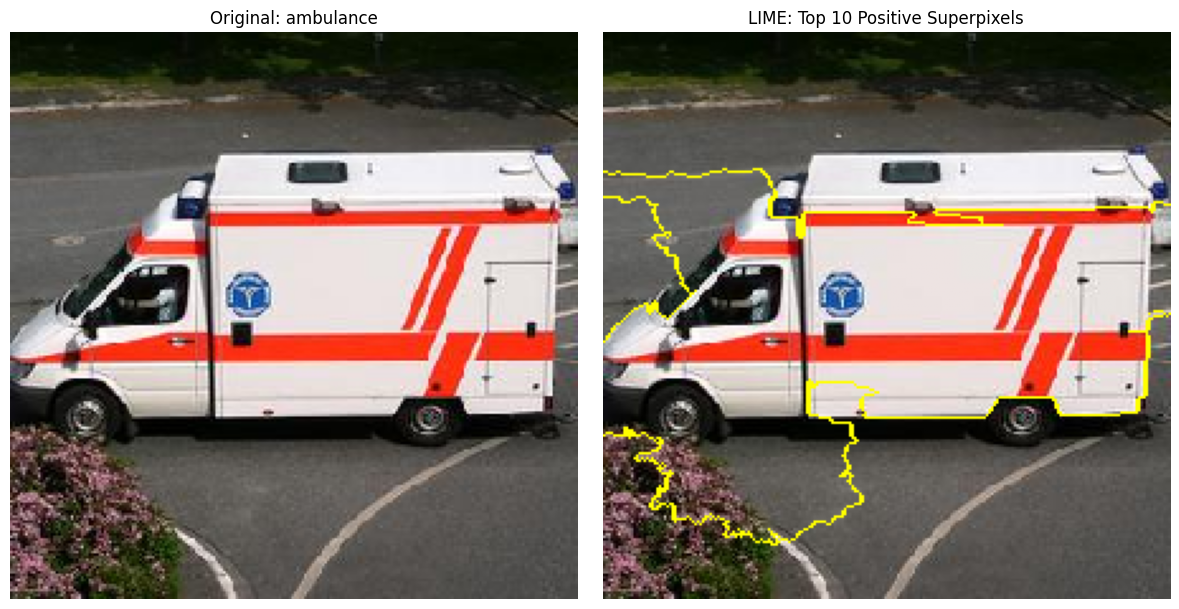

Generating LIME explanation for: banana...


100%|██████████| 1000/1000 [01:29<00:00, 11.20it/s]


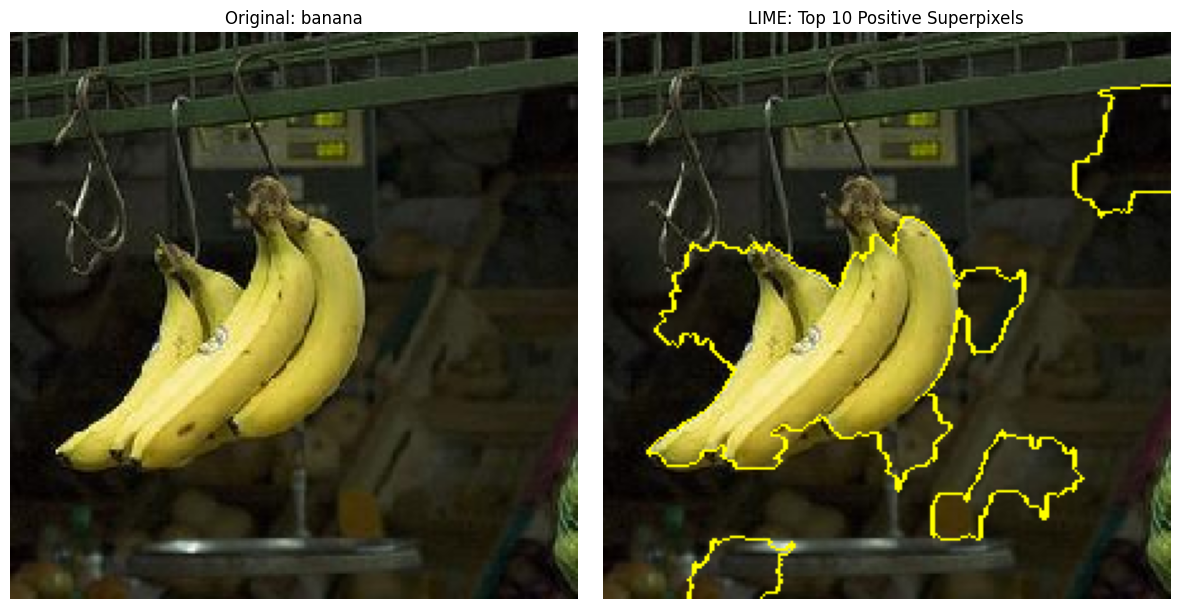

Generating LIME explanation for: castle...


100%|██████████| 1000/1000 [02:08<00:00,  7.79it/s]


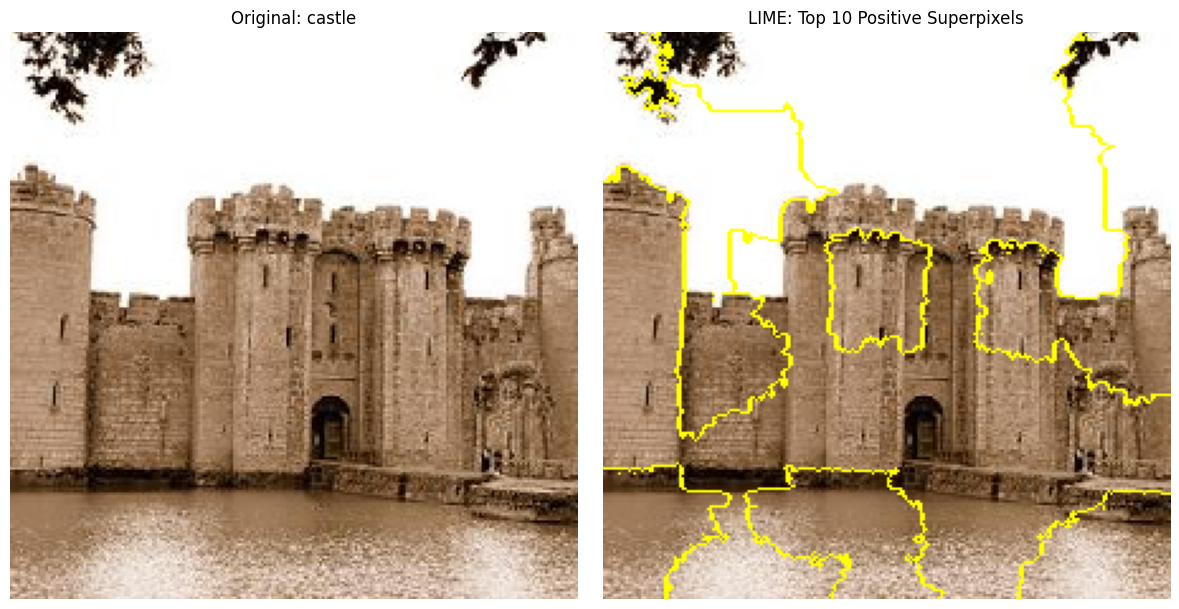

Generating LIME explanation for: cock...


100%|██████████| 1000/1000 [01:14<00:00, 13.39it/s]


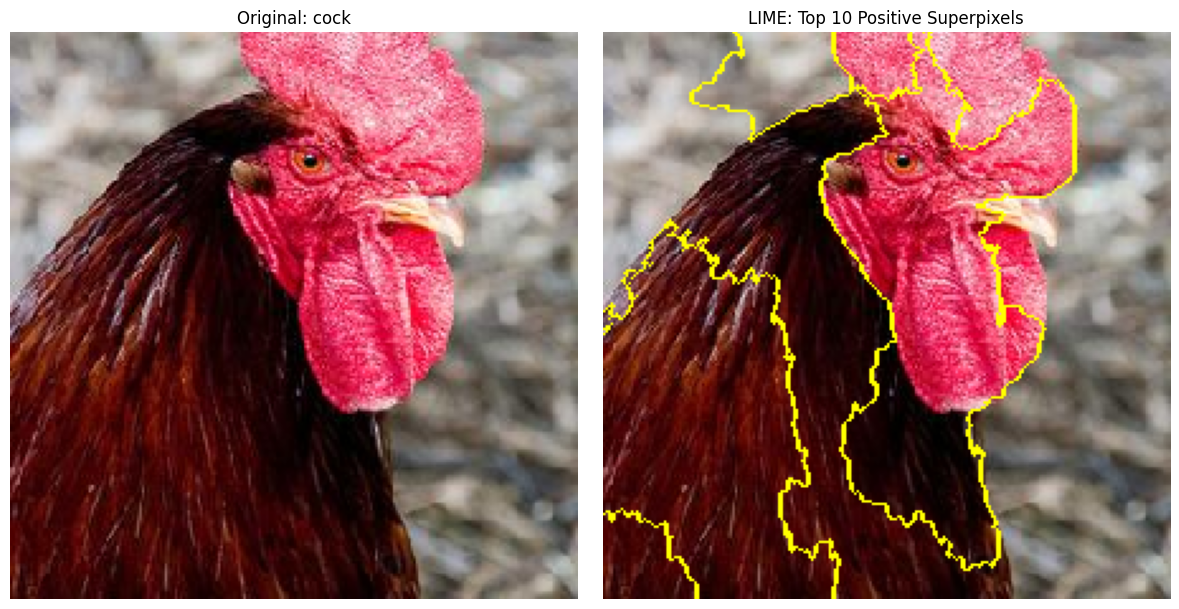

Generating LIME explanation for: African_elephant...


100%|██████████| 1000/1000 [00:47<00:00, 21.11it/s]


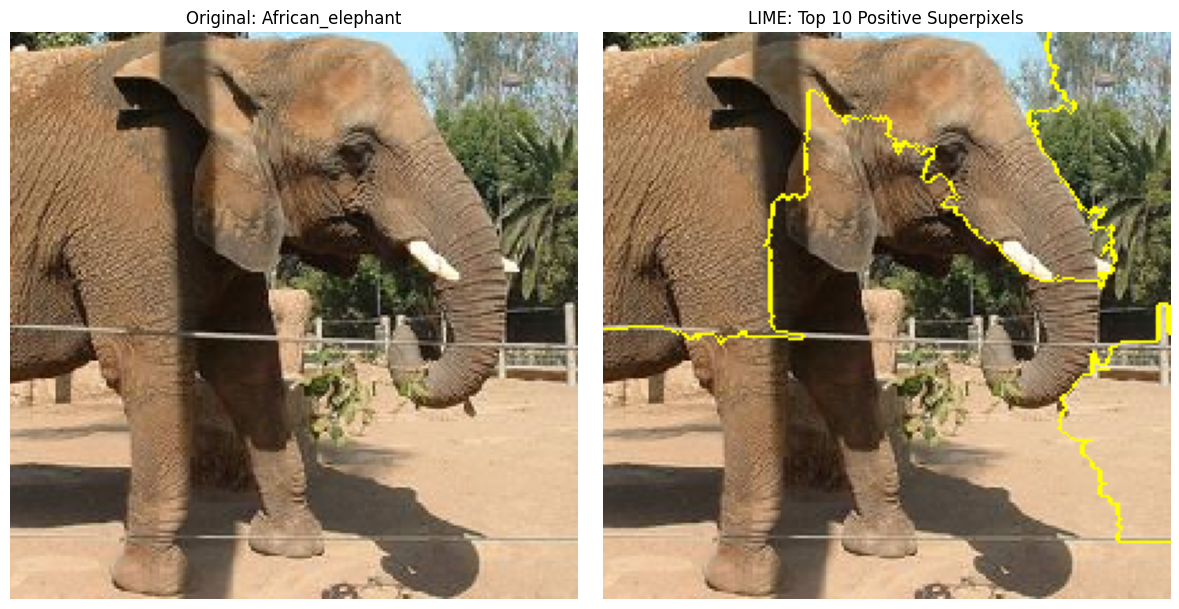

In [6]:
# Create LIME explainer
explainer = lime_image.LimeImageExplainer()

def predict_fn(images):
    images = np.asarray(images, dtype=np.float32)
    return model.predict(preprocess_input(images.copy()), verbose=0)

for i, img in enumerate(images_display):
    print(f"Generating LIME explanation for: {top_predictions[i][1]}...")

    try:
        explanation = explainer.explain_instance(
            img,
            predict_fn,
            top_labels=1,
            hide_color=0,
            num_samples=1000
        )
    except TypeError:
        explanation = explainer.explain_instance(
            img,
            predict_fn,
            top_labels=1,
            hide_color=0,
            num_samples=1000,
            progress_bar=False
        )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ax1.imshow(img)
    ax1.set_title(f"Original: {top_predictions[i][1]}")
    ax1.axis("off")

    ax2.imshow(mark_boundaries(temp / 255.0, mask))
    ax2.set_title("LIME: Top 10 Positive Superpixels")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

### 3. Final Analysis of Results and Interpretability

This section evaluates how the **ResNet50** model perceives the chosen objects and explains the technical reasons behind the varying confidence scores using LIME superpixel masks.

#### **Individual Image Analysis**

*   **Ambulance (1.00):** The model is perfectly certain. LIME highlights the **red stripes** and side panels. However, it also includes parts of the road and bushes, indicating that the model recognizes the "ambulance in its typical context" rather than as an isolated object.
*   **Castle (1.00):** Another perfect score where the model identifies **stone towers and battlements**. Interestingly, large areas of the **sky and water** are also highlighted. This suggests the model associates the presence of a castle with specific scenic landscape features.
*   **Cock / Rooster (0.99):** High confidence is driven by the **red comb and the bird's head**. These are the most biologically distinct features. The LIME mask is tightly clustered around these areas, proving a very accurate focus by the model.
*   **Banana (0.86):** The score is lower due to **background interference**. While the yellow fruit is correctly identified, LIME shows that the **metal hooks and the dark market rack** are also treated as positive evidence. Because these metal objects are not unique to bananas, they introduce mathematical ambiguity, reducing the final score.
*   **Elephant (0.68):** This is the lowest score due to **environmental distraction**. The LIME mask highlights the **horizontal lines of the fence** and background trees as much as the elephant’s trunk. This "noise" dilutes the model's certainty, as the fence is a generic pattern that does not belong exclusively to the elephant class.

#### **Final Conclusions**

The model aligns with human intuition by identifying key features, yet it frequently relies on contextual elements like fences or backgrounds to confirm its decisions. LIME demonstrates that lower confidence scores are a direct result of this environmental noise, successfully providing transparency into the model's decision-making process.